# A metocean drifter with drogue removed and anchor added

- placed at K2 as a realtime SST sensor
- broke free and became a slightly drifting sst sensor

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
sample_data_dir = '/Users/bell/Programs/EcoFOCIpy/'
user_data_dir = '/Users/bell/ecoraid/2024/Moorings/24kum2a/'

In [3]:
###############################################################
# edit to point to {instrument sepcific} raw datafile 
datafile = user_data_dir+'rawconverted/drifter/'
instrument = 'Argos Drifter 237949' #not true - this was on the float
mooring_meta_file = user_data_dir+'logs/24KUM-2A.yaml'
inst_meta_file = sample_data_dir+'staticdata/instr_metaconfig/metoce_cf.yaml'
institution_meta_file = sample_data_dir+'staticdata/institutional_meta_example.yaml' #include uaf?
inst_shortname = 'metoce'


In [4]:
sst = pd.read_csv(datafile+'237949_moored_drifter_sst.csv',parse_dates=True,index_col='time (UTC)')
sst.index = sst.index.rename('date_time')

In [5]:
sst.rename(columns={'sst (degree_C)':'temperature'},inplace=True)

In [6]:
sst.index = sst.index.tz_localize(None)
sst.sort_index(inplace=True)

<Axes: xlabel='date_time'>

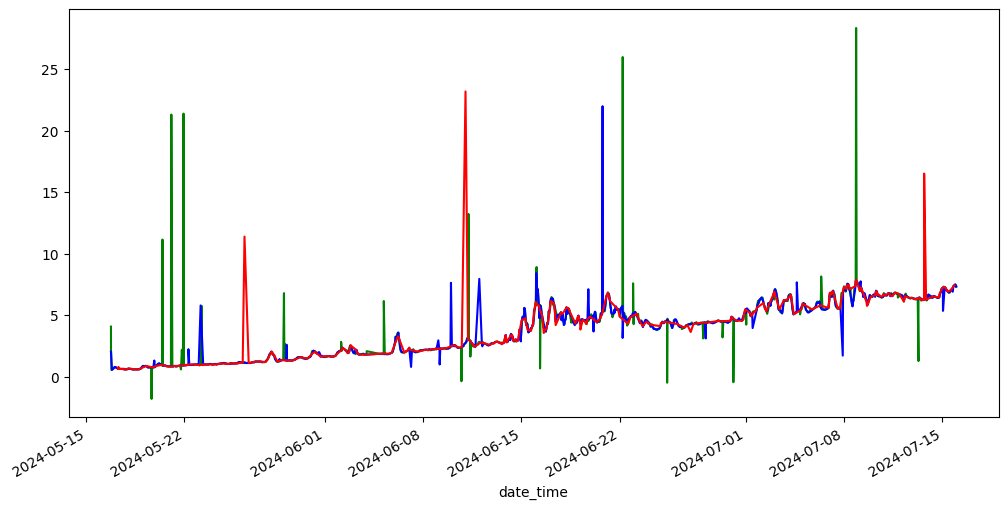

In [7]:
fig, ax = plt.subplots(1,figsize=(12, 6))
sst[sst['location_quality']==1]['temperature'].plot(color='g',ax=ax)
sst[sst['location_quality']==2]['temperature'].plot(color='b',ax=ax)
sst[sst['location_quality']==3]['temperature'].plot(color='r',ax=ax)


In [8]:
# plot against local sbe37

In [9]:
sbe37_data = pd.read_csv(user_data_dir+'initial_archive/24kum2a_s37_0002m.csv',parse_dates=True,index_col='time')

<Axes: xlabel='time'>

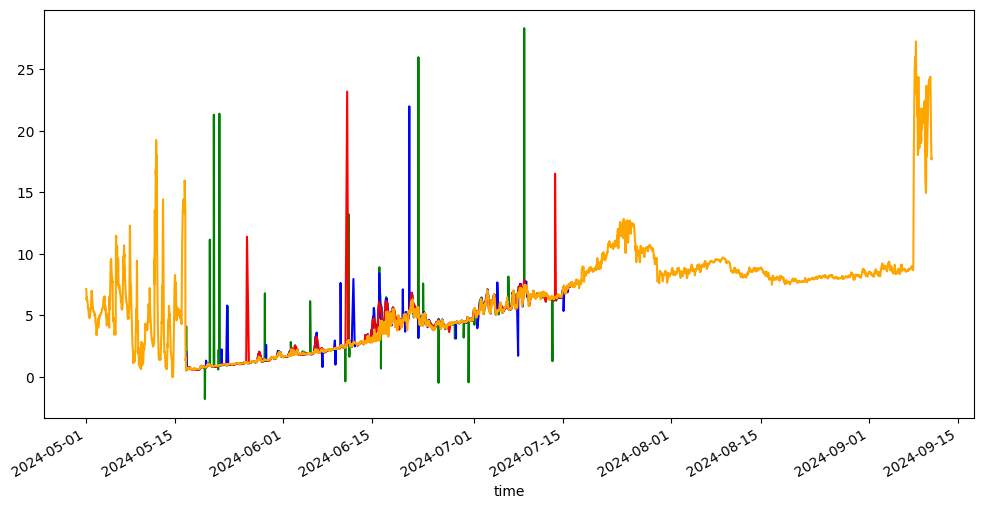

In [10]:
fig, ax = plt.subplots(1,figsize=(12, 6))
sst[sst['location_quality']==1]['temperature'].plot(color='g',ax=ax)
sst[sst['location_quality']==2]['temperature'].plot(color='b',ax=ax)
sst[sst['location_quality']==3]['temperature'].plot(color='r',ax=ax)

sbe37_data.temperature.plot(ax=ax,color='orange')

In [11]:
# save two files for netcdf - pre and post pop

import yaml
import EcoFOCIpy.io.ncCFsave as ncCFsave

## Add Deployment meta information

Two methods are available (if comming from python2 world - ordereddict was important... in py38 a dictionary is inherently ordered)

In [12]:
#just a dictionary of dictionaries - simple
with open(mooring_meta_file) as file:
    mooring_config = yaml.full_load(file)

In [13]:
#just a dictionary of dictionaries - simple
with open(institution_meta_file) as file:
    institution_config = yaml.full_load(file)

## Filter with median filter

trajectory_id               0
strain (percent)            0
voltage (volts)             0
latitude (degrees_north)    0
temperature                 0
location_quality            0
lon360 (degrees_east)       0
longitude (degrees_east)    0
time                        0
dtype: int64
trajectory_id               0
strain (percent)            0
voltage (volts)             0
latitude (degrees_north)    0
temperature                 4
location_quality            0
lon360 (degrees_east)       0
longitude (degrees_east)    0
time                        0
dtype: int64
trajectory_id                0
strain (percent)             0
voltage (volts)              0
latitude (degrees_north)     0
temperature                 18
location_quality             0
lon360 (degrees_east)        0
longitude (degrees_east)     0
temperature_rolling_mean     0
temperature_rolling_std      1
upper_bound                  1
lower_bound                  1
dtype: int64

Quality control process completed for the new fi

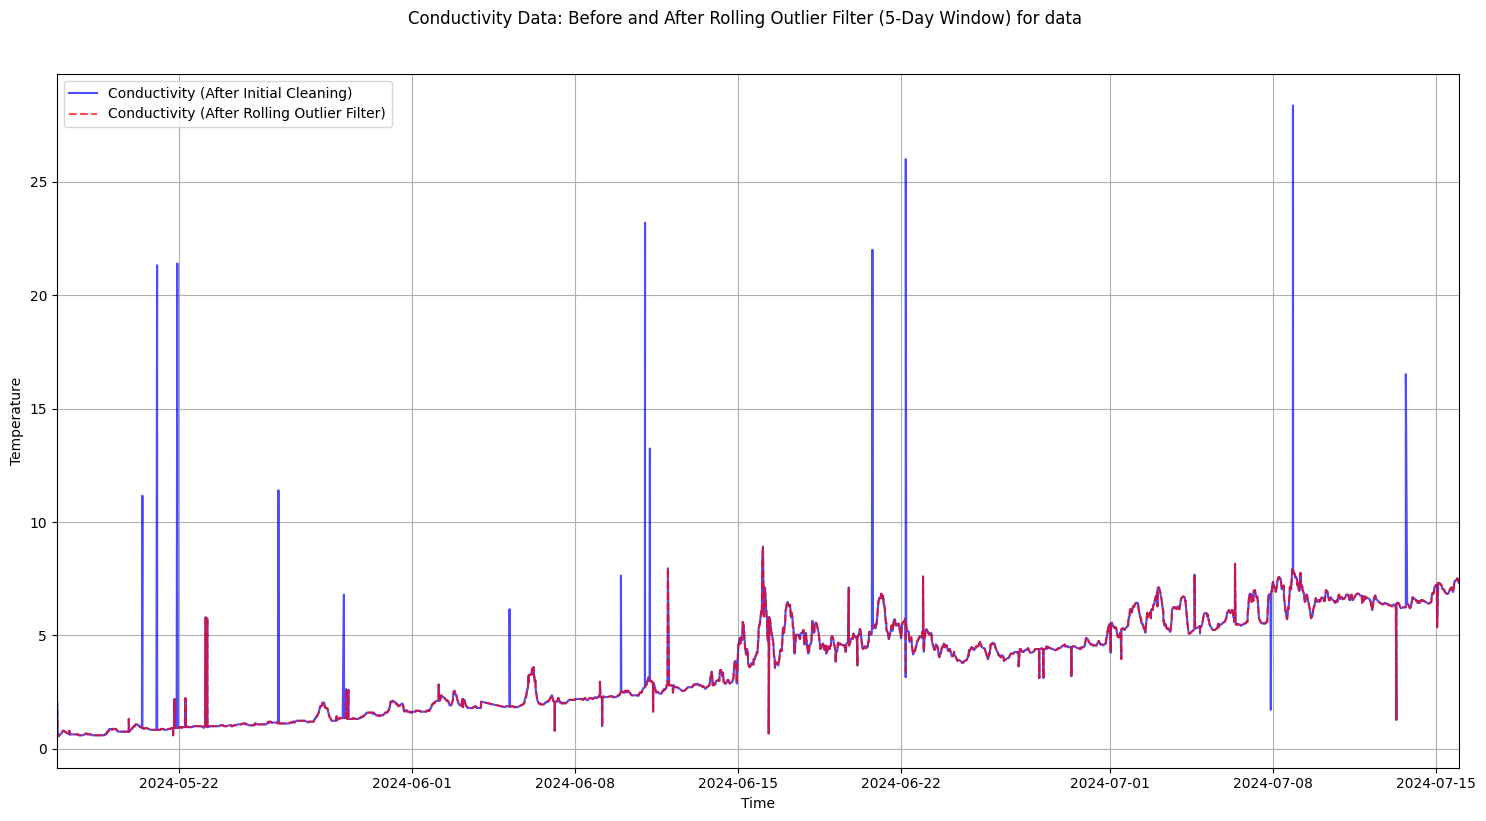

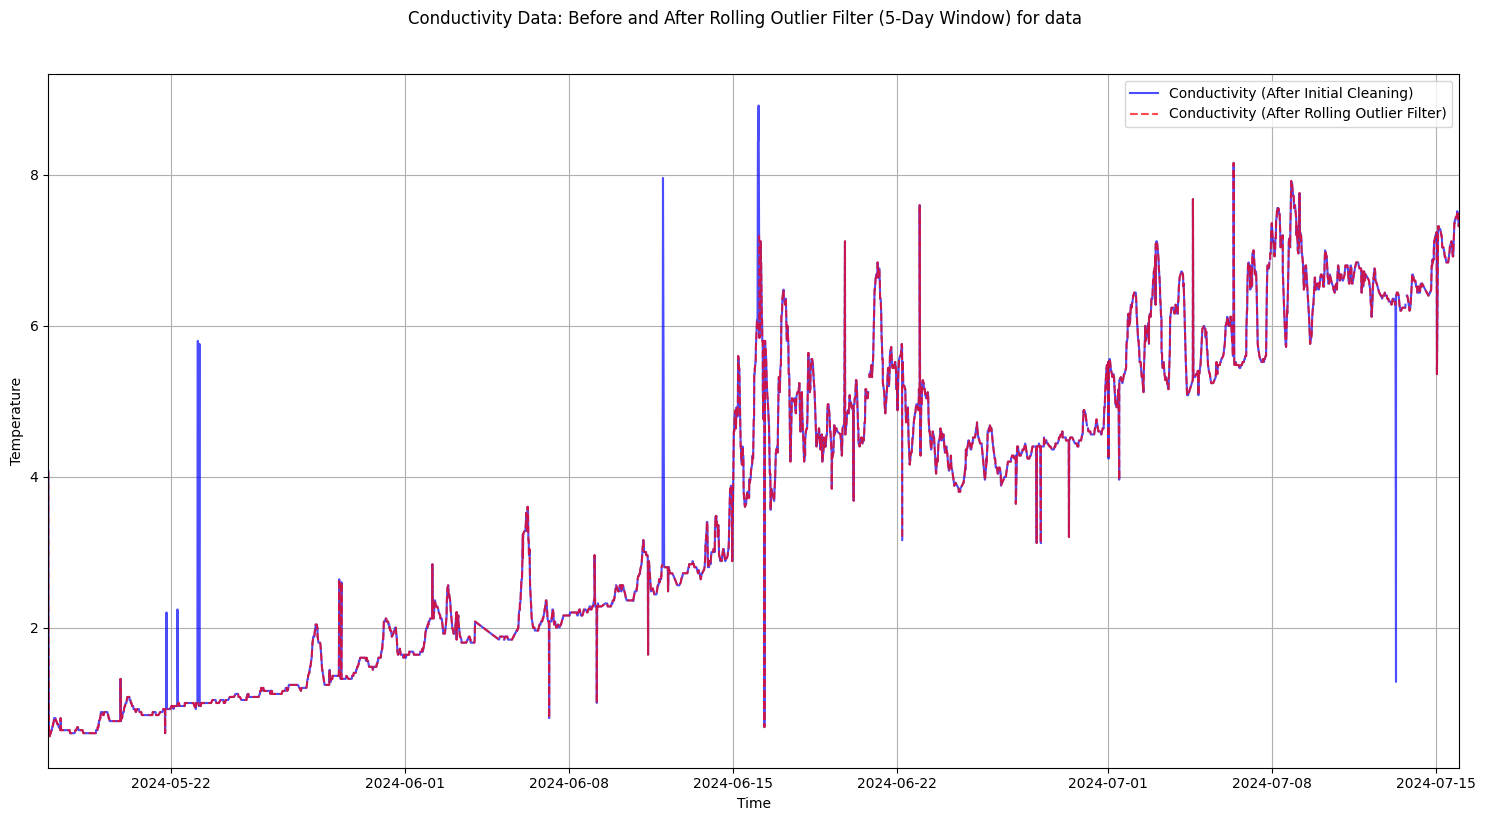

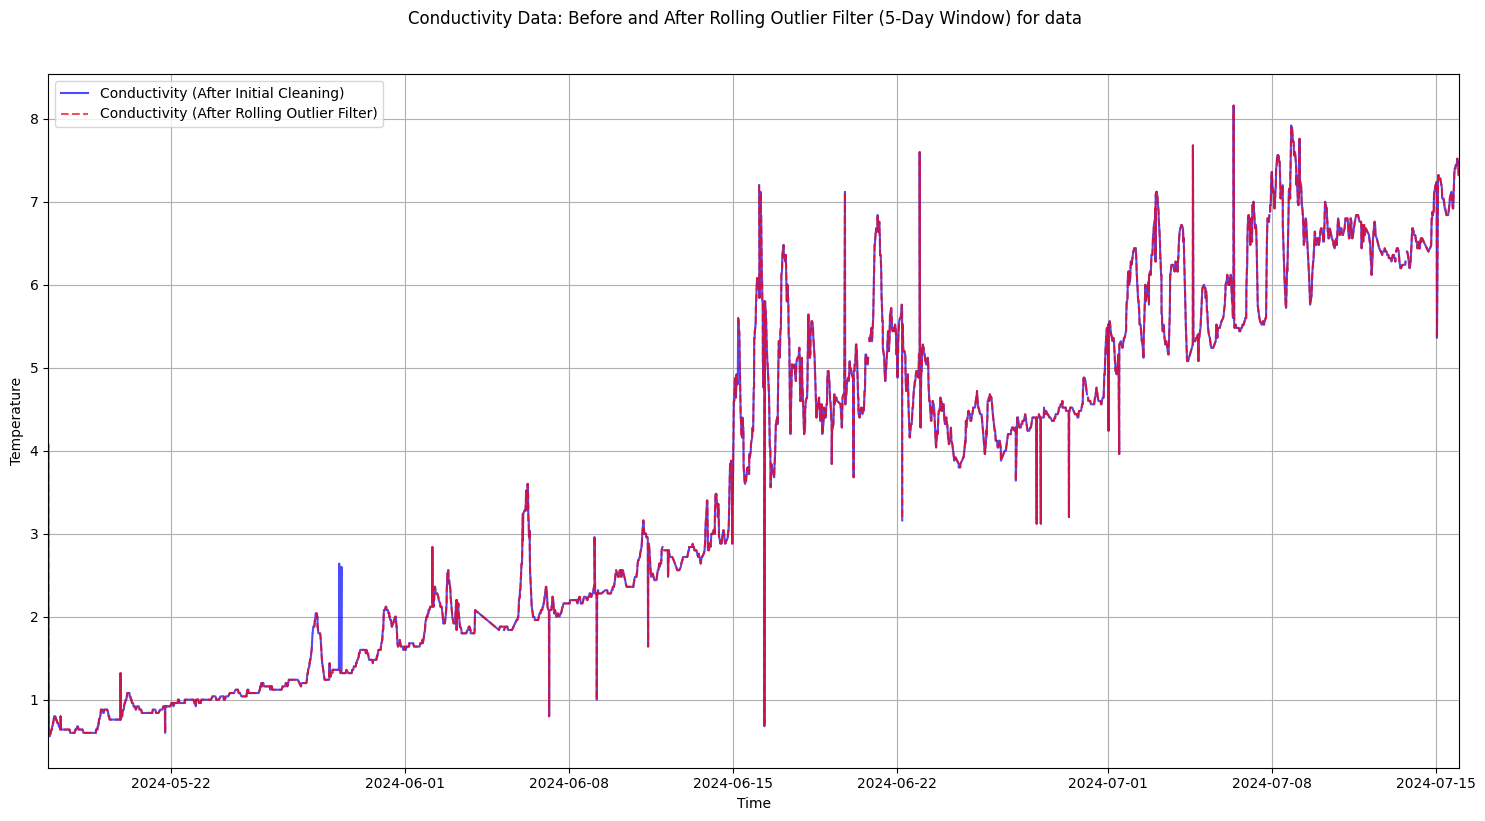

In [14]:
### QC

import datetime

n_pass = 0
while n_pass < 3:
    # --- Step 1: Initial Load and Inspection ---
    df = sst.copy()
    
    # Convert 'time' column to datetime
    df['time'] = df.index
    print(df.isnull().sum())
    
    # --- Step 2: Clean Conductivity < 0.001 and Propagate NaNs ---
    df_cleaned = df.copy()
    
    # Replace conductivity and salinity values with NaN where conductivity is less than 0.001
    # As discussed, salinity is also made NaN due to its correlation with anomalous conductivity
    df_cleaned.loc[df_cleaned['temperature'] < 0.01, ['temperature']] = float('nan')
    
    # Propagate NaNs from conductivity to temperature
    # df_cleaned.loc[df_cleaned['conductivity'].isnull(), 'temperature'] = float('nan')
    print(df_cleaned.isnull().sum())
    
    # --- Step 3: Rolling Filter for Outliers in Conductivity ---
    
    # Set the 'time' column as the index for rolling operations
    df_cleaned_indexed = df_cleaned.set_index('time')
    
    # Store original conductivity (after initial cleaning) for comparison in the next plot
    original_conductivity_for_rolling_plot = df_cleaned_indexed['temperature'].copy()
    
    # Define the rolling window size (5 days)
    window_size = '7D'
    
    # Calculate rolling mean and standard deviation for conductivity
    df_cleaned_indexed['temperature_rolling_mean'] = df_cleaned_indexed['temperature'].rolling(window=window_size).mean()
    df_cleaned_indexed['temperature_rolling_std'] = df_cleaned_indexed['temperature'].rolling(window=window_size).std()
    
    # Define outlier bounds (5 standard deviations)
    num_std_dev = 5
    df_cleaned_indexed['upper_bound'] = df_cleaned_indexed['temperature_rolling_mean'] + num_std_dev * df_cleaned_indexed['temperature_rolling_std']
    df_cleaned_indexed['lower_bound'] = df_cleaned_indexed['temperature_rolling_mean'] - num_std_dev * df_cleaned_indexed['temperature_rolling_std']
    
    # Mark outliers: Replace conductivity values that are outside the bounds with NaN
    outlier_mask = (df_cleaned_indexed['temperature'] > df_cleaned_indexed['upper_bound']) | \
                   (df_cleaned_indexed['temperature'] < df_cleaned_indexed['lower_bound'])
    
    df_cleaned_indexed.loc[outlier_mask, 'temperature'] = float('nan')
    print(df_cleaned_indexed.isnull().sum())
    
    # Reset index to get 'time' back as a column for plotting
    df_cleaned_final = df_cleaned_indexed.reset_index()
    
    # Plot: Conductivity before and after rolling filter
    fig2, ax2 = plt.subplots(figsize=(15, 8))
    fig2.suptitle(f'Conductivity Data: Before and After Rolling Outlier Filter (5-Day Window) for data', y=1.02)
    
    ax2.plot(df_cleaned_final['time'], original_conductivity_for_rolling_plot.reset_index()['temperature'],
             label='Conductivity (After Initial Cleaning)', color='blue', alpha=0.7)
    ax2.plot(df_cleaned_final['time'], df_cleaned_final['temperature'],
             label='Conductivity (After Rolling Outlier Filter)', color='red', linestyle='--', alpha=0.7)
    # ax2.set_ylim([30.0,33])
    ax2.set_xlim([df_cleaned.time.min(),df_cleaned.time.max()])
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Temperature')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    # plt.savefig('rolling_outlier_plot_25bs2a_s16_0021m.png')
    # plt.close(fig2) # This line was used to close the figure and free memory in the execution environment
    
    print("\nQuality control process completed for the new file.")
    
    sst = df_cleaned_final.copy()
    sst.set_index('time',inplace=True)
    sst.index = sst.index.rename('date_time')

    n_pass+=1

## Add Instrument meta information

Time, depth, lat, lon should be added regardless (always our coordinates) but for a mooring site its going to be a (1,1,1,t) dataset
The variables of interest should be read from the data file and matched to a key for naming.  That key is in the inst_config file seen below and should represent common conversion names in the raw data

In [15]:
with open(inst_meta_file) as file:
    inst_config = yaml.full_load(file)

In [16]:
# Add meta data and prelim processing based on meta data
# Convert to xarray and add meta information - save as CF netcdf file
# pass -> data, instmeta, depmeta
metoce_wop_nc = ncCFsave.EcoFOCI_CFnc(df=sst, 
                                instrument_yaml=inst_config, 
                                operation_yaml=mooring_config,
                                operation_type='mooring', 
                                instrument_id=instrument, 
                                inst_shortname=inst_shortname)
metoce_wop_nc

At this point, you could save your file with the `.xarray2netcdf_save()` method and have a functioning dataset.... but it would be very simple with no additional qc, meta-data, or tuned parameters for optimizing software like ferret or erddap.

In [17]:
# expand the dimensions and coordinate variables
# renames them appropriatley and prepares them for meta-filled values
metoce_wop_nc.expand_dimensions()

In [18]:
metoce_wop_nc.variable_meta_data(variable_keys=list(sst.columns.values),drop_missing=True)
metoce_wop_nc.temporal_geospatioal_meta_data(depth='designed')
#adding dimension meta needs to come after updating the dimension values... BUG?
metoce_wop_nc.dimension_meta_data(variable_keys=['depth','latitude','longitude'])

The following steps can happen in just about any order and are all meta-data driven.  Therefore, they are not required to have a functioning dataset, but they are required to have a well described dataset

In [19]:
#add global attributes
metoce_wop_nc.deployment_meta_add()
metoce_wop_nc.get_xdf()

#add instituitonal global attributes
metoce_wop_nc.institution_meta_add(institution_yaml=institution_config)

#add instrument global attributes
metoce_wop_nc.instrument_meta_data()

#add creation date/time - provenance data
metoce_wop_nc.provinance_meta_add()

#provide intial qc status field
metoce_wop_nc.qc_status(qc_status='unknown')

## Save CF Netcdf files

Currently stick to netcdf3 classic... but migrating to netcdf4 (default) may be no problems for most modern purposes.  Its easy enough to pass the `format` kwargs through to the netcdf api of xarray.

In [20]:
# combine trim (not mandatory) and filename together (saves to test.nc without name)

depth = str(int(mooring_config['Instrumentation'][instrument]['DesignedDepth'])).zfill(4)
# mooring_yaml['Instrumentation'][self.instrument_id]['DesignedDepth'])).zfill(4) #<-- alternative
filename = "".join(mooring_config['MooringID'].split('-')).lower()+'_'+inst_shortname+'_'+depth+'m.nc'
metoce_wop_nc.xarray2netcdf_save(xdf = metoce_wop_nc.autotrim_time(),
                           filename=filename,format="NETCDF3_CLASSIC")

# don't trim the data and pass your own filename
# sbe37_wop_nc.xarray2netcdf_save(xdf = sbe37_wop_nc.get_xdf(),
#                            filename=filename,format="NETCDF4_CLASSIC")